MSE  : 2609094001.295853
RMSE : 51079.29131552094
MAE  : 33963.56051499647
R2   : 0.6598457574267022


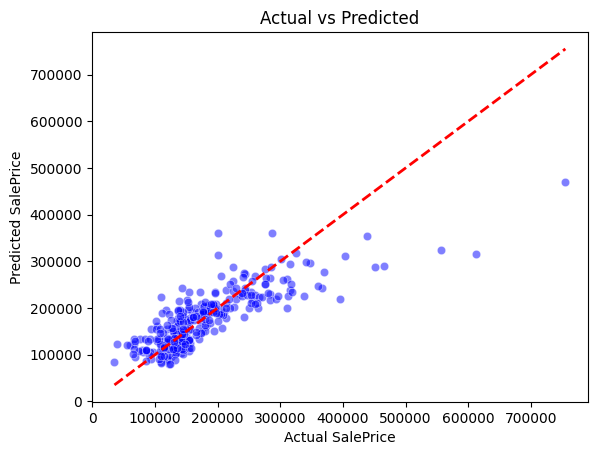

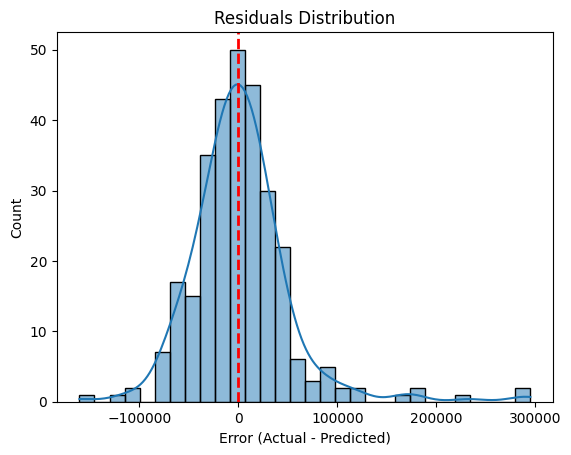

In [ ]:
#  SKILLCRAFT TECHNOLOGY – TASK 01
#  House Price Prediction using Linear Regression
#  Author  : Joshua Pinto
#  Dataset : train.csv  (Kaggle House Prices Dataset)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# DATA
df = pd.read_csv("train.csv")

# Select Features to predict on
FEATURES = ['GrLivArea', 'BedroomAbvGr',
            'FullBath', 'HalfBath',
            'BsmtFullBath', 'BsmtHalfBath']
TARGET = 'SalePrice'

data = df[FEATURES + [TARGET]].dropna()   #
X = data[FEATURES]
y = data[TARGET]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test  = scaler.transform(X_test)       

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)
      
# Prediction 
y_pred = model.predict(X_test)

# Evaluation 
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"MAE  : {mae}")
print(f"R2   : {r2}")


# ACTUAL VS PREDICTED 
plt.figure()
sns.scatterplot(x=y_test, y=y_pred,alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],color='red',lw=2, linestyle='--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted')
plt.show()

# RESIDUALS 
residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Error (Actual - Predicted)')
plt.title('Residuals Distribution')
plt.show()